In [1]:
import pandas as pd

print("Wage analysis starts!")

Wage analysis starts!


In [2]:
import requests
import pandas as pd

url = "https://www.destatis.de"

response = requests.get(url)

print(response.status_code)

200


In [4]:
import os

os.environ["DESTAtIS_TOKEN"] = "ed17039e68c94323ae22e18924c547b1"

In [5]:
token = os.getenv("DESTAtIS_TOKEN")

print("Token loaded:", token is not None)

Token loaded: True


In [8]:
import os
import requests

token = os.getenv("DESTAtIS_TOKEN")

BASE_URL = "https://genesis.destatis.de/genesisWS/rest/2020/"

headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "username": token,
    "password": ""
}

response = requests.post(
    BASE_URL + "data/tablefile",
    headers=headers,
    data={
        "name": "62361-0020",
        "area": "all",
        "format": "csv",
        "language": "en",
        "compress": "false"
    }
)

print(response.status_code)
print(response.text[:1000])

200
PK |6]               62361-0020_1790083924780_en.csve�Kn1��}
o�@3m�r�Q]b�E�� K��8CK#uO s����p�(��]_�=�O?~^Ǜ�ߧQ80N�J��>����.�)o��Z�wS~�e��b>��1�y��u�q�S�-b����c����^�Y��%���.����<O�wZ)��x����wJy
A���$9(�ԴRҐ3��
$2@�E��S� 9��%�Y���4�n@���oe� r�H��0�WR��0M�r���������48B�y��B��E޷k���J�����R�'�4X��%@=K��w�m�>
� 7���\���`NS��mg�2�ٺ$�
�j�~PK;}��  �  PK  |6];}��  �                   62361-0020_1790083924780_en.csvPK      M   �    


In [9]:
from pathlib import Path
import zipfile
import io

# 创建 raw 数据文件夹
raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

# 把 Destatis 返回的 ZIP 保存到内存并解压
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files in ZIP:")
    print(z.namelist())

    # 解压 CSV
    z.extractall(raw_dir)

print("\nData saved to:")
print(raw_dir.resolve())

Files in ZIP:
['62361-0020_1790083924780_en.csv']

Data saved to:
/Users/chenyuting/german-labor-market-analysis-2005-2025/data/raw


In [10]:
list(raw_dir.iterdir())

[PosixPath('../data/raw/62361-0020_1790083924780_en.csv')]

In [15]:
csv_file = list(raw_dir.glob("*.csv"))[0]

df_raw = pd.read_csv(
    csv_file,
    sep=";",
    encoding="utf-8"
)

df_raw.head()

Tabelle: 62361-0020
Real wage index, nominal wage index: Germany, y... nan             nan           nan                                NaN
Earnings survey                                    nan             nan           nan                                NaN
Germany                                            nan             nan           nan                                NaN
nan                                                Real wage index Annual change Nominal wage index       Annual change
                                                   2025=100        in (%)        2025=100                        in (%)

In [12]:
df_raw.shape

(27, 1)

In [16]:
df_raw.head(27)

Tabelle: 62361-0020
Real wage index, nominal wage index: Germany, y... nan             nan           nan                                NaN
Earnings survey                                    nan             nan           nan                                NaN
Germany                                            nan             nan           nan                                NaN
nan                                                Real wage index Annual change Nominal wage index       Annual change
                                                   2025=100        in (%)        2025=100                        in (%)
2007                                               88.8            .             61.7                                 .
2008                                               89.1            +0.3          63.5                              +2.9
2009                                               88.9            -0.2          63.6                              +0.2
2010                                               90.2            +1.5          65.2                              +2.5
2011                                               91.2            +1.1          67.3                              +3.2
2012                                               91.9            +0.8          69.1                              +2.7
2013                                               91.7            -0.2          70.0                              +1.3
2014                                               93.2            +1.6          71.9                              +2.7
2015                                               95.3            +2.3          73.9                              +2.8
2016                                               97.0            +1.8          75.6                              +2.3
2017                                               98.0            +1.0          77.5                              +2.5
2018                                               99.3            +1.3          79.9                              +3.1
2019                                               100.5           +1.2          82.0                              +2.6
2020                                               99.2            -1.3          81.4                              -0.7
2021                                               99.2            -             83.9                              +3.1
2022                                               95.1            -4.1          86.0                              +2.5
2023                                               95.3            +0.2          91.2                              +6.0
2024                                               98.1            +2.9          96.0                              +5.3
2025                                               100.0           +1.9          100.0                             +4.2
__________                                         nan             nan           nan                                NaN
© Federal Statistical Office, Wiesbaden 2026       nan             nan           nan                                NaN
created: 2026-09-22 / 15:32:04                     nan             nan           nan                                NaN

In [18]:
from pathlib import Path

raw_text = Path(csv_file).read_text(encoding="utf-8")
lines = raw_text.splitlines()

for i, line in enumerate(lines[:12]):
    print(i, repr(line))

0 '\ufeffTabelle: 62361-0020'
1 'Real wage index, nominal wage index: Germany, years;;;;'
2 'Earnings survey;;;;'
3 'Germany;;;;'
4 ';Real wage index;Annual change;Nominal wage index;Annual change'
5 ';2025=100;in (%);2025=100;in (%)'
6 '2007;88.8;.;61.7;.'
7 '2008;89.1;+0.3;63.5;+2.9'
8 '2009;88.9;-0.2;63.6;+0.2'
9 '2010;90.2;+1.5;65.2;+2.5'
10 '2011;91.2;+1.1;67.3;+3.2'
11 '2012;91.9;+0.8;69.1;+2.7'


In [20]:
import pandas as pd

df_raw = pd.read_csv(
    csv_file,
    sep=";",
    header=None,
    skiprows=6,
    names=[
        "year",
        "real_wage_index",
        "real_wage_growth",
        "nominal_wage_index",
        "nominal_wage_growth"
    ]
)

df_raw.head(20)

,year,real_wage_index,real_wage_growth,nominal_wage_index,nominal_wage_growth
0,2007,88.8,.,61.7,.
1,2008,89.1,+0.3,63.5,+2.9
2,2009,88.9,-0.2,63.6,+0.2
3,2010,90.2,+1.5,65.2,+2.5
4,2011,91.2,+1.1,67.3,+3.2
5,2012,91.9,+0.8,69.1,+2.7
6,2013,91.7,-0.2,70.0,+1.3
7,2014,93.2,+1.6,71.9,+2.7
8,2015,95.3,+2.3,73.9,+2.8
9,2016,97.0,+1.8,75.6,+2.3


In [21]:
import numpy as np

# 把缺失标记统一转换为 NaN
df_raw = df_raw.replace([".", "-"], np.nan)

# 删除不是年份的数据行
df_raw = df_raw[
    pd.to_numeric(df_raw["year"], errors="coerce").notna()
].copy()

# 转换数据类型
df_raw["year"] = df_raw["year"].astype(int)

numeric_cols = [
    "real_wage_index",
    "real_wage_growth",
    "nominal_wage_index",
    "nominal_wage_growth"
]

df_raw[numeric_cols] = df_raw[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df_raw = df_raw.reset_index(drop=True)

df_raw

,year,real_wage_index,real_wage_growth,nominal_wage_index,nominal_wage_growth
0,2007,88.8,NaN,61.7,NaN
1,2008,89.1,0.3,63.5,2.9
2,2009,88.9,-0.2,63.6,0.2
3,2010,90.2,1.5,65.2,2.5
4,2011,91.2,1.1,67.3,3.2
5,2012,91.9,0.8,69.1,2.7
6,2013,91.7,-0.2,70.0,1.3
7,2014,93.2,1.6,71.9,2.7
8,2015,95.3,2.3,73.9,2.8
9,2016,97.0,1.8,75.6,2.3


In [22]:
print("Rows:", len(df_raw))
print("Years:", df_raw["year"].min(), "-", df_raw["year"].max())
print("\nMissing values:")
print(df_raw.isna().sum())

Rows: 19
Years: 2007 - 2025

Missing values:
year                   0
real_wage_index        0
real_wage_growth       2
nominal_wage_index     0
nominal_wage_growth    1
dtype: int64


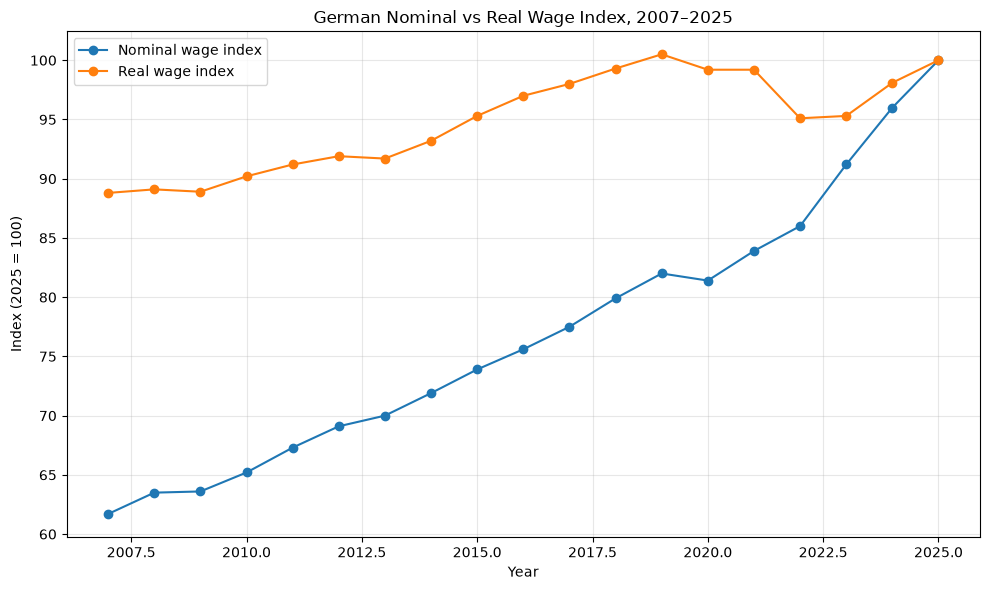

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    df_raw["year"],
    df_raw["nominal_wage_index"],
    marker="o",
    label="Nominal wage index"
)

plt.plot(
    df_raw["year"],
    df_raw["real_wage_index"],
    marker="o",
    label="Real wage index"
)

plt.title("German Nominal vs Real Wage Index, 2007–2025")
plt.xlabel("Year")
plt.ylabel("Index (2025 = 100)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()